In [7]:
%load_ext autoreload
%autoreload 2

import meles
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Download YoutubeFaces

First, we download the YoutubeFaces dataset by requesting the credentials and accessing the [downlaod page](http://www.cslab.openu.ac.il/download/wolftau/). To save on system resources, we will only download the aligned video frames (i.e., `aligned_images_DB.tar.gz`) which are cropped and without audio.


In [ ]:
# !curl -u username:password -L -C - -O http://www.cslab.openu.ac.il/download/wolftau/aligned_images_DB.tar.gz

Next, we need to place the extract the tarball into the `/data/ytfaces` directory. We will use the same directory structure for our dataset.

In [4]:
DATA_PATH = Path("../../data")

# Iterate all directories and create the dataframe. The structure should be 'identity/video/frame'
_structure = []
for identity_dir in DATA_PATH.joinpath("ytfaces").iterdir():
    if not identity_dir.is_dir():
        continue

    # Iterate all videos for the identity. Each video itself contains a list of image files.
    for video_dir in identity_dir.iterdir():
        if not video_dir.is_dir():
            continue

        # Iterate all frames of the video. Each frame should be a image file.
        for frame_file in video_dir.iterdir():
            if not frame_file.is_file():
                continue

            # The frame is added to the structure (flattened) in any order.
            # We can later sort them by their natural ordering. The path is relative to the data
            # directory such that it can be easily used in other files.
            _structure.append({
                'identity': identity_dir.name,
                'video': video_dir.name,
                'frame': frame_file.name,
                'frame_suffix': frame_file.suffix,
                'path': str(frame_file.relative_to(DATA_PATH))
            })

# Build the structure dataframe and store it next to the dataset folder.
structure = pd.DataFrame(_structure)
structure.to_json(DATA_PATH.joinpath("ytfaces.json"))
structure

,identity,video,frame,frame_suffix,path
0,Claudia_Pechstein,5,aligned_detect_5.1700.jpg,.jpg,ytfaces/Claudia_Pechstein/5/aligned_detect_5.1...
1,Claudia_Pechstein,5,aligned_detect_5.1714.jpg,.jpg,ytfaces/Claudia_Pechstein/5/aligned_detect_5.1...
2,Claudia_Pechstein,5,aligned_detect_5.1648.jpg,.jpg,ytfaces/Claudia_Pechstein/5/aligned_detect_5.1...
3,Claudia_Pechstein,5,aligned_detect_5.1674.jpg,.jpg,ytfaces/Claudia_Pechstein/5/aligned_detect_5.1...
4,Claudia_Pechstein,5,aligned_detect_5.1660.jpg,.jpg,ytfaces/Claudia_Pechstein/5/aligned_detect_5.1...
...,...,...,...,...,...
621121,Li_Zhaoxing,3,aligned_detect_3.20.jpg,.jpg,ytfaces/Li_Zhaoxing/3/aligned_detect_3.20.jpg
621122,Li_Zhaoxing,3,aligned_detect_3.9.jpg,.jpg,ytfaces/Li_Zhaoxing/3/aligned_detect_3.9.jpg
621123,Li_Zhaoxing,3,aligned_detect_3.8.jpg,.jpg,ytfaces/Li_Zhaoxing/3/aligned_detect_3.8.jpg
621124,Li_Zhaoxing,3,aligned_detect_3.21.jpg,.jpg,ytfaces/Li_Zhaoxing/3/aligned_detect_3.21.jpg


## Dataset statistics

We now take a short look at the structure of the dataset. The dataset is organised as a hierarchy of `identity / video / frame`, so two quantities are of particular interest:

- **Videos per identity** &mdash; how many distinct videos are available for each person.
- **Frames per video** &mdash; how many aligned frames each individual video contains.

We compute both distributions below and visualise them side by side.

In [5]:
# Number of distinct videos for each identity.
videos_per_identity = structure.groupby("identity")["video"].nunique()

# Number of frames contained in each individual video.
frames_per_video = structure.groupby(["identity", "video"]).size()

print(f"Identities:      {structure['identity'].nunique():>8,}")
print(f"Videos:          {frames_per_video.shape[0]:>8,}")
print(f"Frames:          {len(structure):>8,}")

print("\nVideos per identity")
print(videos_per_identity.describe().to_string())

print("\nFrames per video")
print(frames_per_video.describe().to_string())

Identities:         1,595
Videos:             3,425
Frames:           621,126

Videos per identity
count    1595.000000
mean        2.147335
std         1.152809
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000

Frames per video
count    3425.000000
mean      181.350657
std       268.662806
min        48.000000
25%        63.000000
50%        93.000000
75%       179.000000
max      2157.000000


Matplotlib is building the font cache; this may take a moment.


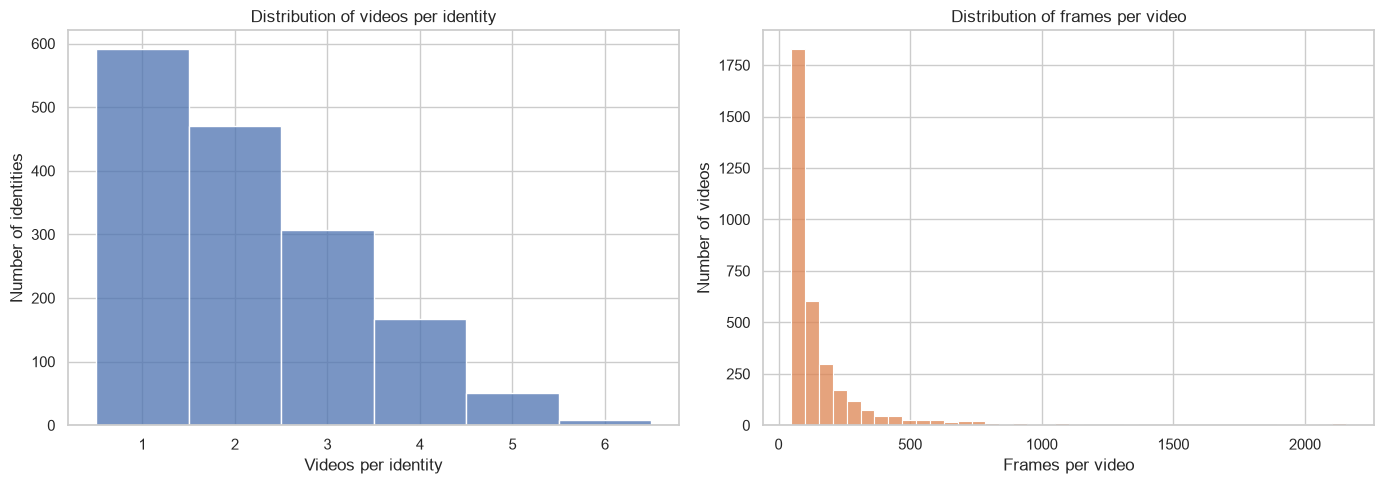

In [6]:
sns.set_theme(style="whitegrid")

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of videos per identity.
sns.histplot(videos_per_identity, discrete=True, color="#4C72B0", ax=ax_left)
ax_left.set_title("Distribution of videos per identity")
ax_left.set_xlabel("Videos per identity")
ax_left.set_ylabel("Number of identities")

# Distribution of frames per video.
sns.histplot(frames_per_video, bins=40, color="#DD8452", ax=ax_right)
ax_right.set_title("Distribution of frames per video")
ax_right.set_xlabel("Frames per video")
ax_right.set_ylabel("Number of videos")

fig.tight_layout()
plt.show()

We can see how most identities only have a single video available with `6` being the maximum. Also, most videos have around `100` frames with 48 being the minimum and going up to `2,157` for some outliers. The frames were generated at 24fps. For our experiment we will use footage with up to 30min with requires `75` frames (the smallest videos are at least 19min long). For videos that are longer than 30min, we will use the first `75` frames and drop the rest. Splitting the video into multiple is not an option, as it would introduce an unnecessary bias with the persistent background.

## Experiment dataset

For the experiments we work with a trimmed-down version of the dataset. We apply two filters:

- **Minimum videos per identity** &mdash; identities with fewer than `MIN_VIDEOS_PER_IDENTITY` videos are dropped entirely, so every remaining identity has enough distinct videos to work with.
- **Maximum frames per video** &mdash; frames are ordered by their natural (frame-index) ordering and only the first `MAX_FRAMES_PER_VIDEO` frames of each video are kept.

The resulting structure dataframe is stored next to the full dataset as `ytfaces_experiment.json`.

In [13]:
# Filter thresholds for the experiment dataset.
MIN_VIDEOS_PER_IDENTITY = 3   # drop identities with fewer than this many videos
MAX_FRAMES_PER_VIDEO = 75     # keep only the first N frames of each video

# Keep only identities that have at least MIN_VIDEOS_PER_IDENTITY videos.
eligible_identities = videos_per_identity[videos_per_identity >= MIN_VIDEOS_PER_IDENTITY].index
experiment = structure[structure["identity"].isin(eligible_identities)].copy()

# Keep only the first MAX_FRAMES_PER_VIDEO frames of each video. To do that, first
# determine the natural ordering of frames within each video via the frame index
# encoded in the file name (e.g. 'aligned_detect_5.1700.jpg' -> 1700) and then drop.
experiment = experiment.sort_values(["identity", "video", "frame"])
experiment = (
    experiment.groupby(["identity", "video"], sort=False)
    .head(MAX_FRAMES_PER_VIDEO)
    .reset_index(drop=True)
)

# Store the experiment structure dataframe next to the dataset folder.
experiment.to_json(DATA_PATH.joinpath("ytfaces_experiment.json"))
experiment

,identity,video,frame,frame_suffix,path
0,Aaron_Eckhart,0,aligned_detect_0.555.jpg,.jpg,ytfaces/Aaron_Eckhart/0/aligned_detect_0.555.jpg
1,Aaron_Eckhart,0,aligned_detect_0.556.jpg,.jpg,ytfaces/Aaron_Eckhart/0/aligned_detect_0.556.jpg
2,Aaron_Eckhart,0,aligned_detect_0.557.jpg,.jpg,ytfaces/Aaron_Eckhart/0/aligned_detect_0.557.jpg
3,Aaron_Eckhart,0,aligned_detect_0.558.jpg,.jpg,ytfaces/Aaron_Eckhart/0/aligned_detect_0.558.jpg
4,Aaron_Eckhart,0,aligned_detect_0.559.jpg,.jpg,ytfaces/Aaron_Eckhart/0/aligned_detect_0.559.jpg
...,...,...,...,...,...
130722,Zulfiqar_Ahmed,4,aligned_detect_4.225.jpg,.jpg,ytfaces/Zulfiqar_Ahmed/4/aligned_detect_4.225.jpg
130723,Zulfiqar_Ahmed,4,aligned_detect_4.226.jpg,.jpg,ytfaces/Zulfiqar_Ahmed/4/aligned_detect_4.226.jpg
130724,Zulfiqar_Ahmed,4,aligned_detect_4.227.jpg,.jpg,ytfaces/Zulfiqar_Ahmed/4/aligned_detect_4.227.jpg
130725,Zulfiqar_Ahmed,4,aligned_detect_4.228.jpg,.jpg,ytfaces/Zulfiqar_Ahmed/4/aligned_detect_4.228.jpg


In [17]:
# Number of distinct videos for each identity.
videos_per_identity = experiment.groupby("identity")["video"].nunique()

# Number of frames contained in each individual video.
frames_per_video = experiment.groupby(["identity", "video"]).size()

print(f"Identities:      {experiment['identity'].nunique():>8,}")
print(f"Videos:          {frames_per_video.shape[0]:>8,}")
print(f"Frames:          {len(experiment):>8,}")

print("\nVideos per identity")
print(videos_per_identity.describe().to_string())

print("\nFrames per video")
print(frames_per_video.describe().to_string())

Identities:           533
Videos:             1,892
Frames:           130,727

Videos per identity
count    533.000000
mean       3.549719
std        0.727975
min        3.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        6.000000

Frames per video
count    1892.000000
mean       69.094609
std         9.078716
min        48.000000
25%        63.000000
50%        75.000000
75%        75.000000
max        75.000000


We now have `130,727` frames over `533` identities where the number of videos and frames are a lot more balanced.

In [ ]:
# What is different from the paper; Finish dataset setup (ytfaces)